# 3. Ensemble XGBoost + Logistic Regression — Irrigation Need

Ensemble entre el mejor XGBoost (modelo base, sin tuning) y un Logistic Regression optimizado.

1. Preprocesamiento (mismo pipeline que notebook 2)
2. XGBoost base — OOF probabilities (5-fold)
3. Logistic Regression optimizado — RandomizedSearchCV + OOF probabilities
4. Ensemble: soft voting (50/50 y ponderado por CV accuracy)
5. Entrenamiento final + submission

**Dataset:** Playground Series S6E4 | **Clases:** Low / Medium / High | **Métrica:** Accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, log_loss
from scipy.stats import loguniform
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Librerías cargadas")

Librerías cargadas


## 1. Carga y Preprocesamiento

In [2]:
train_raw  = pd.read_csv("../data/train.csv")
test_raw   = pd.read_csv("../data/test.csv")
sample_sub = pd.read_csv("../data/sample_submission.csv")

print(f"Train:  {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test:   {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")

Train:  630,000 filas x 21 columnas
Test:   270,000 filas x 20 columnas


In [3]:
TARGET      = "Irrigation_Need"
CLASS_ORDER = ["Low", "Medium", "High"]
LABEL_MAP   = {"Low": 0, "Medium": 1, "High": 2}
INV_MAP     = {0: "Low", 1: "Medium", 2: "High"}

continuas = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
    "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
    "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm"
]
categoricas = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
    "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"
]
features = continuas + categoricas

ids_test = test_raw["id"].values
y = train_raw[TARGET].map(LABEL_MAP).values

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train = train_raw[features].copy()
X_test  = test_raw[features].copy()
X_train[categoricas] = enc.fit_transform(X_train[categoricas])
X_test[categoricas]  = enc.transform(X_test[categoricas])

feature_names = features
X_train = X_train.values.astype(float)
X_test  = X_test.values.astype(float)

# Pesos de muestra: inverso de frecuencia de clase
class_counts   = np.bincount(y)
sample_weights = np.array([1.0 / class_counts[yi] for yi in y])
sample_weights /= sample_weights.mean()

print(f"{'='*65}")
print("PREPROCESAMIENTO COMPLETADO")
print(f"{'='*65}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nDistribución de clases en train:")
for cls, idx in LABEL_MAP.items():
    pct = class_counts[idx] / len(y) * 100
    print(f"  {cls:8s} ({idx}): {class_counts[idx]:>7,}  ({pct:.2f}%)")
print(f"{'='*65}")

PREPROCESAMIENTO COMPLETADO
X_train: (630000, 19)
X_test:  (270000, 19)

Distribución de clases en train:
  Low      (0): 369,917  (58.72%)
  Medium   (1): 239,074  (37.95%)
  High     (2):  21,009  (3.33%)


## 2. XGBoost Base — OOF Probabilities (5-fold)

Usamos el modelo **base** (hiperparámetros por defecto) ya que superó al modelo tuned en el notebook 2 (98.39% vs 98.23%).

In [4]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_xgb   = np.zeros((len(y), 3))
xgb_accs  = []
xgb_losses = []

print(f"{'='*65}")
print("CROSS-VALIDATION — XGBoost Base (5-fold, OOF)")
print(f"{'='*65}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y[tr_idx],       y[val_idx]
    sw_tr       = sample_weights[tr_idx]

    xgb_model.fit(X_tr, y_tr, sample_weight=sw_tr, verbose=False)

    proba = xgb_model.predict_proba(X_val)
    oof_xgb[val_idx] = proba

    acc = accuracy_score(y_val, np.argmax(proba, axis=1))
    ll  = log_loss(y_val, proba)
    xgb_accs.append(acc)
    xgb_losses.append(ll)

    print(f"  Fold {fold}: Accuracy = {acc:.4f}  |  Log-Loss = {ll:.4f}")

xgb_mean_acc  = np.mean(xgb_accs)
xgb_mean_loss = np.mean(xgb_losses)

print(f"{'='*65}")
print(f"  Accuracy: {xgb_mean_acc:.4f} ± {np.std(xgb_accs):.4f}")
print(f"  Log-Loss: {xgb_mean_loss:.4f} ± {np.std(xgb_losses):.4f}")
print(f"{'='*65}")

CROSS-VALIDATION — XGBoost Base (5-fold, OOF)
  Fold 1: Accuracy = 0.9840  |  Log-Loss = 0.0623
  Fold 2: Accuracy = 0.9840  |  Log-Loss = 0.0638
  Fold 3: Accuracy = 0.9836  |  Log-Loss = 0.0642
  Fold 4: Accuracy = 0.9840  |  Log-Loss = 0.0622
  Fold 5: Accuracy = 0.9839  |  Log-Loss = 0.0624
  Accuracy: 0.9839 ± 0.0002
  Log-Loss: 0.0630 ± 0.0008


## 3. Logistic Regression Optimizado

Pipeline: `StandardScaler → LogisticRegression(multinomial, saga)`.  
`RandomizedSearchCV` sobre `C` (log-uniforme) y `class_weight`.

In [5]:
from sklearn.model_selection import train_test_split

# Tunear sobre 20% estratificado (~126k filas) — el rango de C se estima igual con menos datos
X_tune, _, y_tune, _ = train_test_split(
    X_train, y, test_size=0.80, stratify=y, random_state=42
)
print(f"Subsample para tuning: {X_tune.shape[0]:,} filas ({X_tune.shape[0]/len(y)*100:.0f}% del train)")

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",      # más rápido que saga con 19 features
        max_iter=300,        # suficiente con lbfgs y datos escalados
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_lr = {
    "lr__C":            loguniform(1e-3, 1e3),
    "lr__class_weight": [None, "balanced"],
}

rs_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist_lr,
    n_iter=10,                                                      # era 20
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), # era 5
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_lr.fit(X_tune, y_tune)

best_lr_params = rs_lr.best_params_
best_lr_score  = rs_lr.best_score_

print(f"\n{'='*65}")
print("MEJORES HIPERPARÁMETROS — Logistic Regression")
print(f"{'='*65}")
for k, v in best_lr_params.items():
    print(f"  {k:30s}: {v}")
print(f"\n  CV Accuracy (mejor, subsample): {best_lr_score:.4f}")
print(f"{'='*65}")

Subsample para tuning: 126,000 filas (20% del train)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

MEJORES HIPERPARÁMETROS — Logistic Regression
  lr__C                         : 3.907967156822881
  lr__class_weight              : None

  CV Accuracy (mejor, subsample): 0.7500


In [6]:
best_pipe_lr = rs_lr.best_estimator_

oof_lr    = np.zeros((len(y), 3))
lr_accs   = []
lr_losses = []

print(f"{'='*65}")
print("CROSS-VALIDATION — Logistic Regression Optimizado (5-fold, OOF)")
print(f"{'='*65}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y[tr_idx],       y[val_idx]

    best_pipe_lr.fit(X_tr, y_tr)

    proba = best_pipe_lr.predict_proba(X_val)
    oof_lr[val_idx] = proba

    acc = accuracy_score(y_val, np.argmax(proba, axis=1))
    ll  = log_loss(y_val, proba)
    lr_accs.append(acc)
    lr_losses.append(ll)

    print(f"  Fold {fold}: Accuracy = {acc:.4f}  |  Log-Loss = {ll:.4f}")

lr_mean_acc  = np.mean(lr_accs)
lr_mean_loss = np.mean(lr_losses)

print(f"{'='*65}")
print(f"  Accuracy: {lr_mean_acc:.4f} ± {np.std(lr_accs):.4f}")
print(f"  Log-Loss: {lr_mean_loss:.4f} ± {np.std(lr_losses):.4f}")
print(f"{'='*65}")

CROSS-VALIDATION — Logistic Regression Optimizado (5-fold, OOF)
  Fold 1: Accuracy = 0.7493  |  Log-Loss = 0.5256
  Fold 2: Accuracy = 0.7495  |  Log-Loss = 0.5256
  Fold 3: Accuracy = 0.7496  |  Log-Loss = 0.5261
  Fold 4: Accuracy = 0.7479  |  Log-Loss = 0.5279
  Fold 5: Accuracy = 0.7478  |  Log-Loss = 0.5284
  Accuracy: 0.7488 ± 0.0008
  Log-Loss: 0.5267 ± 0.0012


## 4. Ensemble — Soft Voting

Comparamos dos estrategias sobre las probabilidades OOF:
- **50/50**: promedio simple
- **Ponderado**: pesos proporcionales al CV accuracy individual

In [7]:
# --- Ensemble 50/50 ---
oof_50_50 = 0.5 * oof_xgb + 0.5 * oof_lr
acc_50_50 = accuracy_score(y, np.argmax(oof_50_50, axis=1))
ll_50_50  = log_loss(y, oof_50_50)

# --- Ensemble ponderado por CV accuracy ---
total_acc = xgb_mean_acc + lr_mean_acc
w_xgb = xgb_mean_acc / total_acc
w_lr  = lr_mean_acc  / total_acc

oof_weighted = w_xgb * oof_xgb + w_lr * oof_lr
acc_weighted = accuracy_score(y, np.argmax(oof_weighted, axis=1))
ll_weighted  = log_loss(y, oof_weighted)

# --- Resumen comparativo ---
print(f"{'='*65}")
print("COMPARATIVA — Accuracy OOF")
print(f"{'='*65}")
print(f"  XGBoost base          : {xgb_mean_acc:.4f}  (Log-Loss: {xgb_mean_loss:.4f})")
print(f"  Logit optimizado      : {lr_mean_acc:.4f}  (Log-Loss: {lr_mean_loss:.4f})")
print(f"  Ensemble 50/50        : {acc_50_50:.4f}  (Log-Loss: {ll_50_50:.4f})")
print(f"  Ensemble ponderado    : {acc_weighted:.4f}  (Log-Loss: {ll_weighted:.4f})")
print(f"    w_xgb={w_xgb:.3f}  w_lr={w_lr:.3f}")
print(f"{'='*65}")

# Seleccionar la mejor estrategia
results = {
    "XGBoost base":       xgb_mean_acc,
    "Logit optimizado":   lr_mean_acc,
    "Ensemble 50/50":     acc_50_50,
    "Ensemble ponderado": acc_weighted,
}
best_strategy = max(results, key=results.get)
print(f"\n  >> Mejor estrategia: {best_strategy} ({results[best_strategy]:.4f})")

COMPARATIVA — Accuracy OOF
  XGBoost base          : 0.9839  (Log-Loss: 0.0630)
  Logit optimizado      : 0.7488  (Log-Loss: 0.5267)
  Ensemble 50/50        : 0.9833  (Log-Loss: 0.2291)
  Ensemble ponderado    : 0.9842  (Log-Loss: 0.2016)
    w_xgb=0.568  w_lr=0.432

  >> Mejor estrategia: Ensemble ponderado (0.9842)


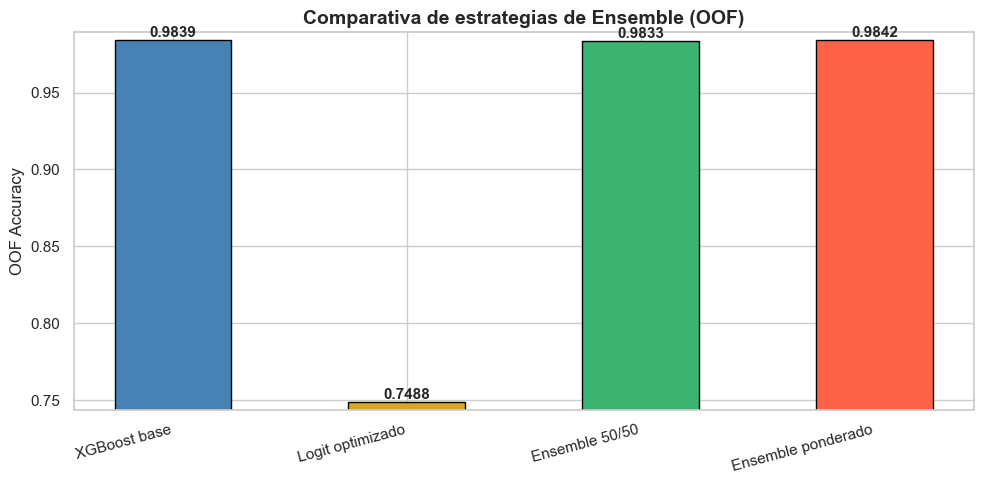

In [8]:
labels = list(results.keys())
accs   = list(results.values())
colors = ["steelblue", "goldenrod", "mediumseagreen", "tomato"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor="black", width=0.5)

for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f"{acc:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_ylim(min(accs) - 0.005, max(accs) + 0.005)
ax.set_ylabel("OOF Accuracy", fontsize=12)
ax.set_title("Comparativa de estrategias de Ensemble (OOF)", fontsize=14, fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 5. Entrenamiento Final y Submission

Entrenamos ambos modelos sobre **todo el train** y aplicamos el ensemble ponderado para generar las predicciones finales.

In [9]:
print("Entrenando XGBoost base sobre todo el train...")
xgb_final = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train, y, sample_weight=sample_weights, verbose=False)
print("  XGBoost listo.")

print("Entrenando Logit optimizado sobre todo el train...")
lr_final = rs_lr.best_estimator_
lr_final.fit(X_train, y)
print("  Logit listo.")

# Predicciones en test
proba_xgb_test = xgb_final.predict_proba(X_test)
proba_lr_test  = lr_final.predict_proba(X_test)

# Aplicar la misma ponderación elegida
proba_ensemble_test = w_xgb * proba_xgb_test + w_lr * proba_lr_test
test_preds  = np.argmax(proba_ensemble_test, axis=1)
test_labels = [INV_MAP[i] for i in test_preds]

print(f"\n{'='*65}")
print("PREDICCIONES SOBRE TEST")
print(f"{'='*65}")
print(f"Registros: {len(test_labels):,}")
print(f"\nDistribución predicha:")
pred_counts = pd.Series(test_labels).value_counts().reindex(["Low", "Medium", "High"])
for cls, cnt in pred_counts.items():
    print(f"  {cls:8s}: {cnt:>7,}  ({cnt/len(test_labels)*100:.2f}%)")
print(f"{'='*65}")

Entrenando XGBoost base sobre todo el train...
  XGBoost listo.
Entrenando Logit optimizado sobre todo el train...
  Logit listo.

PREDICCIONES SOBRE TEST
Registros: 270,000

Distribución predicha:
  Low     : 159,709  (59.15%)
  Medium  : 101,336  (37.53%)
  High    :   8,955  (3.32%)


In [10]:
import os

submission = pd.DataFrame({
    "id":         ids_test,
    TARGET:       test_labels
})

submission_path = "../data/3_ensemble_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"{'='*65}")
print("SUBMISSION GENERADA")
print(f"{'='*65}")
print(f"Archivo:  {os.path.abspath(submission_path)}")
print(f"Filas:    {len(submission):,}")
print(f"\nPrimeras filas:")
print(submission.head(5).to_string(index=False))
print(f"\n--- Resumen de modelos ---")
print(f"  XGBoost base          : {xgb_mean_acc:.4f} ± {np.std(xgb_accs):.4f}")
print(f"  Logit optimizado      : {lr_mean_acc:.4f} ± {np.std(lr_accs):.4f}")
print(f"  Ensemble ponderado    : {acc_weighted:.4f}  (w_xgb={w_xgb:.3f}, w_lr={w_lr:.3f})")
print(f"  Ensemble 50/50        : {acc_50_50:.4f}")
print(f"{'='*65}")

SUBMISSION GENERADA
Archivo:  c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\DGKaggle\Playground Series\Season 6\Episode 4 - Predicting Irrigation Need\data\3_ensemble_submission.csv
Filas:    270,000

Primeras filas:
    id Irrigation_Need
630000             Low
630001          Medium
630002             Low
630003             Low
630004             Low

--- Resumen de modelos ---
  XGBoost base          : 0.9839 ± 0.0002
  Logit optimizado      : 0.7488 ± 0.0008
  Ensemble ponderado    : 0.9842  (w_xgb=0.568, w_lr=0.432)
  Ensemble 50/50        : 0.9833


## 6. Envío a Kaggle

In [11]:
import sys
!{sys.executable} -m pip install --upgrade kaggle --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
COMPETITION = "playground-series-s6e4"
FILE        = "../data/3_ensemble_submission.csv"
MSG         = f"Ensemble XGBoost base + Logit optimizado - soft voting ponderado - Acc={acc_weighted:.4f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Irrigation Need


  0%|          | 0.00/3.39M [00:00<?, ?B/s]
  0%|          | 16.0k/3.39M [00:00<00:43, 81.0kB/s]
  6%|▌         | 192k/3.39M [00:00<00:04, 704kB/s]  
 15%|█▌        | 528k/3.39M [00:00<00:03, 891kB/s]
 18%|█▊        | 624k/3.39M [00:00<00:03, 731kB/s]
 58%|█████▊    | 1.97M/3.39M [00:00<00:00, 3.36MB/s]
100%|██████████| 3.39M/3.39M [00:01<00:00, 1.95MB/s]
